In [ ]:
pip show pytesseract

In [ ]:
!pip install opencv-python pandas pytesseract scikit-image networkx
# You also need to install Google's Tesseract OCR engine on your system.

In [4]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install torchvision

# P&ID to Excel

In [2]:
import base64
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from sahi.slicing import slice_image
from inference_sdk import InferenceHTTPClient
import torch
from torchvision.ops import nms # Import nms from torchvision

# --- 1. CONFIGURATION ---
# Your Roboflow API client
CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="ezRD6iXIbVeZMHDl6T28"  # REPLACE WITH YOUR ACTUAL API KEY
)

# Paths for input and output files
input_image_path = "3.png"
output_excel_path = "predictions_with_components.xlsx"
output_image_path = "sample_output.png"

# Create a mapping dictionary from the class numbers to component names
class_mapping = {
    '1': 'Gate Valve', '2': 'Globe Valve', '3': 'Ball Valve', '4': 'Check Valve', '5': 'Pressure Instrument',
    '6': 'Control Valve', '7': 'Tagged Gate Valve', '8': 'Local Control Station', '9': 'Butterfly Valve',
    '10': 'Equipment Tag', '11': 'Diaphragm Valve', '12': 'Plug Valve', '13': 'Needle Valve',
    '14': 'Solenoid Valve', '15': 'Actuated Gate Valve', '16': 'Manual Butterfly Valve',
    '17': 'Safety Relief Valve', '18': 'Process Line Valve', '19': 'Level Instrument',
    '20': 'Flow Instrument', '21': 'Inline Strainer', '22': 'Speciality Valve',
    '23': 'Junction Box ID', '24': 'System Interface', '25': 'Tagged Control Valve',
    '26': 'Temperature Instrument', '27': 'High-Pressure Valve',
    '28': 'Utility Line Valve', '29': 'Drain Valve', '30': 'Operator Station',
    '31': 'Tagged Ball Valve', '32': 'Analysis Instrument'
}

# --- 2. SAHI SLICING & INFERENCE ---
# Load the image using Pillow and convert to a NumPy array for slicing
image_pil = Image.open(input_image_path)
image_np = np.array(image_pil)

# Use SAHI to slice the image with 1024x1024 dimensions
sliced_image_list = slice_image(
    image_np,
    slice_height=1024,
    slice_width=1024,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
)

# A list to store all the predictions from all slices
all_predictions = []

# Loop through each slice and send it to the Roboflow API
for sliced_image in sliced_image_list:
    slice_data = sliced_image['image']

    # Get the starting coordinates from the 'starting_pixel' key
    y_start, x_start = sliced_image['starting_pixel']

    # Encode the sliced image to base64
    slice_pil = Image.fromarray(slice_data)
    slice_pil.save("temp_slice.png")
    with open("temp_slice.png", "rb") as f:
        img_base64 = base64.b64encode(f.read()).decode("utf-8")

    # Perform inference on the slice
    result = CLIENT.infer(img_base64, model_id="pid-aoiv1-nnhgu/1")

    # Adjust and store the predictions
    for prediction in result['predictions']:
        prediction['x'] += y_start
        prediction['y'] += x_start
        all_predictions.append(prediction)

# --- 3. APPLY NON-MAXIMUM SUPPRESSION (NMS) ---

# Convert predictions to a format suitable for NMS
# torchvision.ops.nms expects boxes in [x1, y1, x2, y2] format and scores
boxes = []
scores = []
# Store original prediction indices to retrieve full prediction info after NMS
original_indices = []

for i, p in enumerate(all_predictions):
    x_center, y_center, width, height, confidence = p['x'], p['y'], p['width'], p['height'], p['confidence']
    x1 = x_center - width / 2
    y1 = y_center - height / 2
    x2 = x_center + width / 2
    y2 = y_center + height / 2
    boxes.append([x1, y1, x2, y2])
    scores.append(confidence)
    original_indices.append(i)


if boxes:
    boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
    scores_tensor = torch.tensor(scores, dtype=torch.float32)

    # Apply NMS
    # torchvision.ops.nms(boxes, scores, iou_threshold)
    keep_indices_tensor = nms(boxes_tensor, scores_tensor, iou_threshold=0.45)

    # Filter the original predictions based on NMS output
    # Use the original_indices to map back to the full prediction dictionaries
    final_predictions = [all_predictions[original_indices[i]] for i in keep_indices_tensor]
else:
    final_predictions = []

# --- 4. EXCEL FILE GENERATION ---

# Create a DataFrame from the final predictions
df = pd.DataFrame(final_predictions)

# Create the new 'Component Name' column by mapping the 'class' column
df['Component Name'] = df['class'].map(class_mapping)

# Save the DataFrame to an Excel file
output_excel_path = "predictions_with_components.xlsx"
df.to_excel(output_excel_path, index=False)
print(f"DataFrame with mapped component names successfully saved to {output_excel_path}.")

# --- 5. IMAGE VISUALIZATION ---

# Load the original image using OpenCV
image = cv2.imread(input_image_path)

if image is None:
    print(f"Error: Could not load image from {input_image_path}")
else:
    # Iterate through each row in the DataFrame
    for index, row in df.iterrows():
        # Get coordinates from the DataFrame
        x_center, y_center = row['x'], row['y']
        width, height = row['width'], row['height']
        class_id = row['class'] # Use 'class' which is string from Roboflow API

        # Convert center coordinates to top-left corner coordinates
        x1 = int(x_center - width / 2)
        y1 = int(y_center - height / 2)
        x2 = int(x_center + width / 2)
        y2 = int(y_center + height / 2)

        # Draw the bounding box (rectangle) on the image
        color = (0, 255, 0)  # Green color in BGR format
        thickness = 2
        cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness)

        # Get the component name from the mapping dictionary
        component_name = class_mapping.get(class_id, "Unknown")
        label = f"{class_id}: {component_name}"

        # Put the class number and component name text on the image
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.5
        font_thickness = 1
        text_color = (0, 0, 255)  # Red color for text

        cv2.putText(image, label, (x1, y1 - 10), font, font_scale, text_color, font_thickness)

    # Save the output image with bounding boxes
    cv2.imwrite(output_image_path, image)

    print(f"Image with bounding boxes saved to {output_image_path}")

DataFrame with mapped component names successfully saved to predictions_with_components.xlsx.
Image with bounding boxes saved to sample_output.png


In [3]:
# ===================================================================
# --- P&ID Digitalization Pipeline ---
# ===================================================================
# This script performs a full pipeline:
# 1. Loads a P&ID image and component location data.
# 2. Erases components and intelligently reconstructs pipelines.
# 3. Cleans the image and generates a pipeline skeleton.
# 4. Traces the skeleton to find all line segments, junctions, and endpoints.
# 5. Simplifies the traced paths for efficient storage.
# 6. Exports all structured data to a single JSON file.
# ===================================================================

import cv2
import pandas as pd
import numpy as np
from skimage.morphology import skeletonize
import json

# ===================================================================
# 1. CONFIGURATION
# ===================================================================
# --- Input Paths ---
IMAGE_PATH = '3.png'
COMPONENTS_EXCEL_PATH = 'predictions_with_components.xlsx'

# --- Output Paths ---
OUTPUT_SKELETON_PATH = 'skeleton_final.png'
JSON_OUTPUT_PATH = 'pid_digital_twin.json'

# --- Tuning Parameters ---
# Padding around components to erase
COMPONENT_ERASURE_PADDING = 15
# Thickness of the reconstructed line segment (should match average pipe thickness)
RECONSTRUCTION_LINE_THICKNESS = 5
# Epsilon for path simplification (RDP algorithm). Higher value = more simplification.
PATH_SIMPLIFICATION_EPSILON = 2.0


# ===================================================================
# 2. HELPER CLASSES AND FUNCTIONS
# ===================================================================
class NumpyEncoder(json.JSONEncoder):
    """ Custom encoder for numpy data types for JSON serialization. """
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return json.JSONEncoder.default(self, obj)

def simplify_path(path, epsilon):
    """ Simplifies a path using the Ramer-Douglas-Peucker algorithm. """
    if len(path) < 2:
        return path
    path_np = np.array(path, dtype=np.int32).reshape((-1, 1, 2))
    simplified_path_np = cv2.approxPolyDP(path_np, epsilon, closed=False)
    return [tuple(p) for p in simplified_path_np.reshape((-1, 2))]

def find_key_points(skeleton_image):
    """ Finds all endpoints (1 neighbor) and junctions (>2 neighbors). """
    kernel = np.array([[1, 1, 1], [1, 10, 1], [1, 1, 1]], dtype=np.uint8)
    skeleton_binary = skeleton_image // 255
    neighbor_count_image = cv2.filter2D(skeleton_binary, -1, kernel)
    
    endpoint_coords = np.argwhere(neighbor_count_image == 11)
    junction_coords = np.argwhere(neighbor_count_image > 12)
    
    endpoints = [tuple(p) for p in endpoint_coords]
    junctions = [tuple(p) for p in junction_coords]
    
    return endpoints, junctions

def trace_segments(skeleton_image, key_points):
    """ Traces all line segments between any two key points. """
    skeleton_binary = skeleton_image // 255
    visited = set()
    all_segments = []

    for start_node in key_points:
        for dy, dx in [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]:
            ny, nx = start_node[0] + dy, start_node[1] + dx

            if 0 <= ny < skeleton_binary.shape[0] and 0 <= nx < skeleton_binary.shape[1] and \
               skeleton_binary[ny, nx] == 1 and (ny, nx) not in visited:

                current_path = [start_node]
                curr_y, curr_x = ny, nx

                while (curr_y, curr_x) not in key_points:
                    if (curr_y, curr_x) in visited: break
                    visited.add((curr_y, curr_x))
                    current_path.append((curr_y, curr_x))
                    
                    found_next = False
                    for ddy, ddx in [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]:
                        next_y, next_x = curr_y + ddy, curr_x + ddx
                        if 0 <= next_y < skeleton_binary.shape[0] and 0 <= next_x < skeleton_binary.shape[1] and \
                           skeleton_binary[next_y, next_x] == 1 and (next_y, next_x) not in visited:
                            curr_y, curr_x = next_y, next_x
                            found_next = True
                            break
                    if not found_next: break
                
                current_path.append((curr_y, curr_x))
                for pixel in current_path: visited.add(pixel)
                all_segments.append(current_path)
    return all_segments

# ===================================================================
# 3. MAIN PIPELINE LOGIC
# ===================================================================
def main():
    """ Executes the full P&ID digitalization pipeline. """
    print("--- Starting P&ID Digitalization Pipeline ---")
    
    # === STAGE 1: LOAD DATA ===
    print("1. Loading input files...")
    try:
        source_image = cv2.imread(IMAGE_PATH)
        if source_image is None: raise FileNotFoundError(f"Image not found at {IMAGE_PATH}")
        df_components = pd.read_excel(COMPONENTS_EXCEL_PATH)
    except Exception as e:
        print(f"❌ Error loading files: {e}")
        return

    # === STAGE 2: PRE-PROCESS AND ERASE COMPONENTS ===
    print("2. Pre-processing image and isolating pipelines...")
    gray_image = cv2.cvtColor(source_image, cv2.COLOR_BGR2GRAY)
    binary_image = cv2.adaptiveThreshold(
        gray_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 15, 8
    )

    # Erase components and reconstruct lines
    for _, row in df_components.iterrows():
        x_center, y_center = row['x'], row['y']
        width, height = row['width'], row['height']
        
        x1 = int(x_center - width / 2)
        y1 = int(y_center - height / 2)
        x2 = int(x_center + width / 2)
        y2 = int(y_center + height / 2)

        p1_x = max(0, x1 - COMPONENT_ERASURE_PADDING)
        p1_y = max(0, y1 - COMPONENT_ERASURE_PADDING)
        p2_x = min(source_image.shape[1], x2 + COMPONENT_ERASURE_PADDING)
        p2_y = min(source_image.shape[0], y2 + COMPONENT_ERASURE_PADDING)
        
        # --- Line Reconstruction Logic ---
        roi_mask = np.zeros(binary_image.shape, dtype=np.uint8)
        cv2.rectangle(roi_mask, (p1_x, p1_y), (p2_x, p2_y), 255, -1)
        intersection = cv2.bitwise_and(binary_image, roi_mask)
        contours, _ = cv2.findContours(intersection, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if len(contours) == 2:
            M1 = cv2.moments(contours[0])
            cx1 = int(M1['m10'] / M1['m00']) if M1['m00'] != 0 else 0
            cy1 = int(M1['m01'] / M1['m00']) if M1['m00'] != 0 else 0
            
            M2 = cv2.moments(contours[1])
            cx2 = int(M2['m10'] / M2['m00']) if M2['m00'] != 0 else 0
            cy2 = int(M2['m01'] / M2['m00']) if M2['m00'] != 0 else 0
            
            if cx1 > 0 and cx2 > 0:
                cv2.line(binary_image, (cx1, cy1), (cx2, cy2), 255, RECONSTRUCTION_LINE_THICKNESS)
        
        # Erase the component area from the binary image *after* reconstruction
        cv2.rectangle(binary_image, (p1_x, p1_y), (p2_x, p2_y), 0, -1)

    # === STAGE 3: CLEAN AND SKELETONIZE ===
    print("3. Cleaning binary image and performing skeletonization...")
    binary_image = cv2.morphologyEx(binary_image, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    binary_image = cv2.morphologyEx(binary_image, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    
    skeleton = skeletonize(binary_image / 255).astype(np.uint8) * 255
    cv2.imwrite(OUTPUT_SKELETON_PATH, skeleton)
    print(f"   - Skeleton image saved to '{OUTPUT_SKELETON_PATH}'")

    # === STAGE 4: VECTORIZE SKELETON ===
    print("4. Vectorizing skeleton to extract coordinates...")
    endpoints, junctions = find_key_points(skeleton)
    all_key_points = set(endpoints + junctions)
    
    raw_segments = trace_segments(skeleton, all_key_points)
    
    # === STAGE 5: SIMPLIFY AND DE-DUPLICATE PATHS ===
    print("5. Simplifying paths and removing duplicates...")
    simplified_segments = [simplify_path(seg, PATH_SIMPLIFICATION_EPSILON) for seg in raw_segments]
    
    unique_segments = []
    seen_segments = set()
    for seg in simplified_segments:
        if len(seg) < 2: continue
        endpoint1 = tuple(seg[0])
        endpoint2 = tuple(seg[-1])
        segment_key = tuple(sorted((endpoint1, endpoint2)))
        
        if segment_key not in seen_segments:
            unique_segments.append(seg)
            seen_segments.add(segment_key)
            
    print(f"   - Original segments: {len(raw_segments)}, Unique simplified segments: {len(unique_segments)}")

    # === STAGE 6: EXPORT TO JSON ===
    print(f"6. Exporting final data to '{JSON_OUTPUT_PATH}'...")
    # Convert coordinates from (row, col) to (x, y) for standard representation
    segments_xy = [[(p[1], p[0]) for p in seg] for seg in unique_segments]
    junctions_xy = [(p[1], p[0]) for p in junctions]
    endpoints_xy = [(p[1], p[0]) for p in endpoints]

    pid_data = {
        "image_dimensions": {
            "width": source_image.shape[1],
            "height": source_image.shape[0]
        },
        "components": df_components.to_dict('records'),
        "lines": {
            "segments": segments_xy,
            "junctions": junctions_xy,
            "endpoints": endpoints_xy
        }
    }
    
    with open(JSON_OUTPUT_PATH, 'w') as f:
        json.dump(pid_data, f, indent=2, cls=NumpyEncoder)
        
    print("\n✅ Pipeline complete! Digital twin data saved successfully.")

# ===================================================================
# 4. SCRIPT EXECUTION
# ===================================================================
if __name__ == "__main__":
    main()

--- Starting P&ID Digitalization Pipeline ---
1. Loading input files...
2. Pre-processing image and isolating pipelines...
3. Cleaning binary image and performing skeletonization...
   - Skeleton image saved to 'skeleton_final.png'
4. Vectorizing skeleton to extract coordinates...
5. Simplifying paths and removing duplicates...
   - Original segments: 16228, Unique simplified segments: 13354
6. Exporting final data to 'pid_digital_twin.json'...

✅ Pipeline complete! Digital twin data saved successfully.


### Image to Reconstructed Image

--- Starting Verification Process ---
✅ Drawing 109 components...
✅ Drawing 13354 line segments...
✅ Drawing 9969 junctions...
✅ Drawing 7912 endpoints...

🚀 Displaying the verification image. Close the window to exit.


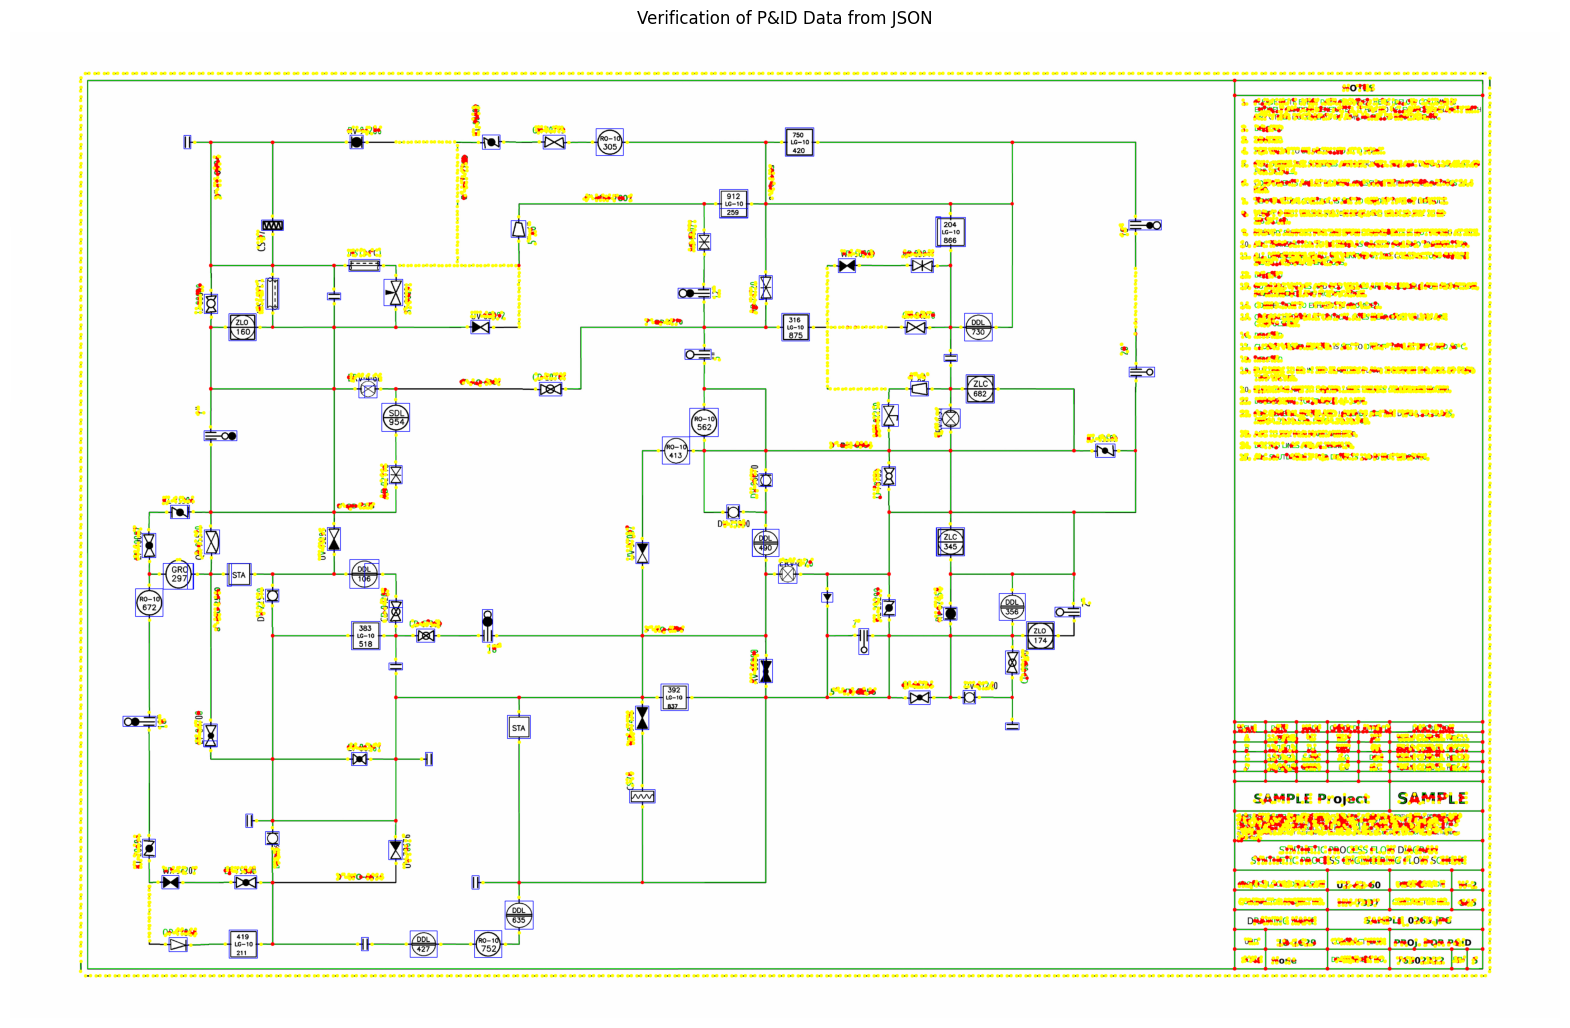

In [4]:
import json
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ===================================================================
# 1. CONFIGURATION
# ===================================================================
# --- Input Paths ---
# Path to the original P&ID image used in the main script
ORIGINAL_IMAGE_PATH = '3.png'
# Path to the JSON file generated by the main script
JSON_PATH = 'pid_digital_twin.json'

# --- Visualization Colors (BGR format for OpenCV) ---
COLOR_COMPONENT = (255, 0, 0)   # Blue
COLOR_LINE = (0, 255, 0)         # Green
COLOR_JUNCTION = (0, 0, 255)     # Red
COLOR_ENDPOINT = (0, 255, 255)   # Yellow

# ===================================================================
# 2. VERIFICATION LOGIC
# ===================================================================
def verify_from_json(image_path, json_path):
    """
    Loads a P&ID image and its corresponding JSON data, then
    draws the detected components and lines to visually verify accuracy.
    """
    print("--- Starting Verification Process ---")
    
    # --- Step 1: Load the original image and JSON data ---
    try:
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Original image not found at {image_path}")
            
        with open(json_path, 'r') as f:
            pid_data = json.load(f)
    except Exception as e:
        print(f"❌ Error loading files: {e}")
        return

    # Create a copy of the image to draw on
    overlay_image = image.copy()
    
    # --- Step 2: Draw Components ---
    print(f"✅ Drawing {len(pid_data.get('components', []))} components...")
    for comp in pid_data.get('components', []):
        x_center, y_center = comp['x'], comp['y']
        width, height = comp['width'], comp['height']
        x1 = int(x_center - width / 2)
        y1 = int(y_center - height / 2)
        x2 = int(x_center + width / 2)
        y2 = int(y_center + height / 2)
        # Draw a blue rectangle for the component's bounding box
        cv2.rectangle(overlay_image, (x1, y1), (x2, y2), COLOR_COMPONENT, 2)

    # --- Step 3: Draw Line Segments ---
    lines_data = pid_data.get('lines', {})
    print(f"✅ Drawing {len(lines_data.get('segments', []))} line segments...")
    for segment in lines_data.get('segments', []):
        # Convert list of points to a NumPy array for drawing
        points = np.array(segment, dtype=np.int32)
        # Draw a green polyline for the segment
        cv2.polylines(overlay_image, [points], isClosed=False, color=COLOR_LINE, thickness=2)

    # --- Step 4: Draw Junctions and Endpoints ---
    print(f"✅ Drawing {len(lines_data.get('junctions', []))} junctions...")
    for junc in lines_data.get('junctions', []):
        # Draw a red circle for each junction
        cv2.circle(overlay_image, tuple(junc), radius=8, color=COLOR_JUNCTION, thickness=-1)
        
    print(f"✅ Drawing {len(lines_data.get('endpoints', []))} endpoints...")
    for endp in lines_data.get('endpoints', []):
        # Draw a yellow circle for each endpoint
        cv2.circle(overlay_image, tuple(endp), radius=8, color=COLOR_ENDPOINT, thickness=-1)

    # --- Step 5: Display the final image ---
    print("\n🚀 Displaying the verification image. Close the window to exit.")
    # Convert BGR (OpenCV) to RGB (Matplotlib) for correct color display
    rgb_image = cv2.cvtColor(overlay_image, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(20, 15))
    plt.imshow(rgb_image)
    plt.title('Verification of P&ID Data from JSON')
    plt.axis('off') # Hide axes
    plt.show()


# ===================================================================
# 3. SCRIPT EXECUTION
# ===================================================================
if __name__ == "__main__":
    verify_from_json(ORIGINAL_IMAGE_PATH, JSON_PATH)

### Image to Json Format

In [5]:
# process_pid.py

import cv2
import pandas as pd
import numpy as np
from skimage.morphology import skeletonize
import json

# ===================================================================
# 1. CONFIGURATION
# ===================================================================
IMAGE_PATH = '3.png'
COMPONENTS_EXCEL_PATH = 'predictions_with_components.xlsx'
OUTPUT_SKELETON_PATH = 'skeleton_final.png'
JSON_OUTPUT_PATH = 'pid_digital_twin.json'

COMPONENT_ERASURE_PADDING = 15
RECONSTRUCTION_LINE_THICKNESS = 5
PATH_SIMPLIFICATION_EPSILON = 2.0

# ===================================================================
# 2. HELPER CLASSES AND FUNCTIONS
# ===================================================================
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer): return int(obj)
        elif isinstance(obj, np.floating): return float(obj)
        elif isinstance(obj, np.ndarray): return obj.tolist()
        return json.JSONEncoder.default(self, obj)

def simplify_path(path, epsilon):
    if len(path) < 2: return path
    path_np = np.array(path, dtype=np.int32).reshape((-1, 1, 2))
    simplified_path_np = cv2.approxPolyDP(path_np, epsilon, closed=False)
    return [tuple(p) for p in simplified_path_np.reshape((-1, 2))]

def find_key_points(skeleton_image):
    kernel = np.array([[1, 1, 1], [1, 10, 1], [1, 1, 1]], dtype=np.uint8)
    skeleton_binary = skeleton_image // 255
    neighbor_count_image = cv2.filter2D(skeleton_binary, -1, kernel)
    endpoint_coords = np.argwhere(neighbor_count_image == 11)
    junction_coords = np.argwhere(neighbor_count_image > 12)
    return [tuple(p) for p in endpoint_coords], [tuple(p) for p in junction_coords]

def trace_segments(skeleton_image, key_points):
    skeleton_binary = skeleton_image // 255
    visited, all_segments = set(), []
    for start_node in key_points:
        for dy, dx in [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]:
            ny, nx = start_node[0] + dy, start_node[1] + dx
            if 0 <= ny < skeleton_binary.shape[0] and 0 <= nx < skeleton_binary.shape[1] and \
               skeleton_binary[ny, nx] == 1 and (ny, nx) not in visited:
                current_path = [start_node]
                curr_y, curr_x = ny, nx
                while (curr_y, curr_x) not in key_points:
                    if (curr_y, curr_x) in visited: break
                    visited.add((curr_y, curr_x))
                    current_path.append((curr_y, curr_x))
                    found_next = False
                    for ddy, ddx in [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]:
                        next_y, next_x = curr_y + ddy, curr_x + ddx
                        if 0 <= next_y < skeleton_binary.shape[0] and 0 <= next_x < skeleton_binary.shape[1] and \
                           skeleton_binary[next_y, next_x] == 1 and (next_y, next_x) not in visited:
                            curr_y, curr_x = next_y, next_x
                            found_next = True
                            break
                    if not found_next: break
                current_path.append((curr_y, curr_x))
                for pixel in current_path: visited.add(pixel)
                all_segments.append(current_path)
    return all_segments

# ===================================================================
# 3. MAIN PIPELINE LOGIC
# ===================================================================
def main():
    print("--- Starting P&ID Digitalization Pipeline (Image to JSON) ---")
    
    try:
        source_image = cv2.imread(IMAGE_PATH)
        if source_image is None: raise FileNotFoundError(f"Image not found at {IMAGE_PATH}")
        df_components = pd.read_excel(COMPONENTS_EXCEL_PATH)
    except Exception as e:
        print(f"❌ Error loading files: {e}"); return

    gray_image = cv2.cvtColor(source_image, cv2.COLOR_BGR2GRAY)
    binary_image = cv2.adaptiveThreshold(gray_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 15, 8)

    for _, row in df_components.iterrows():
        x_center, y_center, width, height = row['x'], row['y'], row['width'], row['height']
        x1, y1 = int(x_center - width/2), int(y_center - height/2)
        x2, y2 = int(x_center + width/2), int(y_center + height/2)
        p1_x, p1_y = max(0, x1 - COMPONENT_ERASURE_PADDING), max(0, y1 - COMPONENT_ERASURE_PADDING)
        p2_x, p2_y = min(source_image.shape[1], x2 + COMPONENT_ERASURE_PADDING), min(source_image.shape[0], y2 + COMPONENT_ERASURE_PADDING)
        
        roi_mask = np.zeros(binary_image.shape, dtype=np.uint8)
        cv2.rectangle(roi_mask, (p1_x, p1_y), (p2_x, p2_y), 255, -1)
        intersection = cv2.bitwise_and(binary_image, roi_mask)
        contours, _ = cv2.findContours(intersection, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if len(contours) == 2:
            M1 = cv2.moments(contours[0]); cx1, cy1 = (int(M1['m10']/M1['m00']), int(M1['m01']/M1['m00'])) if M1['m00'] != 0 else (0,0)
            M2 = cv2.moments(contours[1]); cx2, cy2 = (int(M2['m10']/M2['m00']), int(M2['m01']/M2['m00'])) if M2['m00'] != 0 else (0,0)
            if cx1 > 0 and cx2 > 0: cv2.line(binary_image, (cx1, cy1), (cx2, cy2), 255, RECONSTRUCTION_LINE_THICKNESS)
        
        cv2.rectangle(binary_image, (p1_x, p1_y), (p2_x, p2_y), 0, -1)

    binary_image = cv2.morphologyEx(binary_image, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    binary_image = cv2.morphologyEx(binary_image, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    
    skeleton = skeletonize(binary_image / 255).astype(np.uint8) * 255
    cv2.imwrite(OUTPUT_SKELETON_PATH, skeleton)
    
    endpoints, junctions = find_key_points(skeleton)
    raw_segments = trace_segments(skeleton, set(endpoints + junctions))
    simplified_segments = [simplify_path(seg, PATH_SIMPLIFICATION_EPSILON) for seg in raw_segments]
    
    unique_segments, seen_segments = [], set()
    for seg in simplified_segments:
        if len(seg) < 2: continue
        segment_key = tuple(sorted((tuple(seg[0]), tuple(seg[-1]))))
        if segment_key not in seen_segments:
            unique_segments.append(seg); seen_segments.add(segment_key)
            
    pid_data = {
        "image_dimensions": {"width": source_image.shape[1], "height": source_image.shape[0]},
        "components": df_components.to_dict('records'),
        "lines": {
            "segments": [[(p[1], p[0]) for p in seg] for seg in unique_segments],
            "junctions": [(p[1], p[0]) for p in junctions],
            "endpoints": [(p[1], p[0]) for p in endpoints]
        }
    }
    
    with open(JSON_OUTPUT_PATH, 'w') as f:
        json.dump(pid_data, f, indent=2, cls=NumpyEncoder)
        
    print(f"\n✅ Pipeline complete! Digital twin data saved to '{JSON_OUTPUT_PATH}'")

# ===================================================================
# 4. SCRIPT EXECUTION
# ===================================================================
if __name__ == "__main__":
    main()

--- Starting P&ID Digitalization Pipeline (Image to JSON) ---

✅ Pipeline complete! Digital twin data saved to 'pid_digital_twin.json'


### Json to Image

In [6]:
# reconstruct_pid.py

import json
import cv2
import numpy as np

# ===================================================================
# 1. CONFIGURATION
# ===================================================================
JSON_PATH = 'pid_digital_twin.json'
OUTPUT_IMAGE_PATH = 'reconstructed_pid.png'

LINE_COLOR = (0, 0, 0)       # Black
LINE_THICKNESS = 2
COMPONENT_COLOR = (0, 0, 0)
JUNCTION_RADIUS = 5

# ===================================================================
# 2. SYMBOL LIBRARY (Add more functions for your symbols)
# ===================================================================
def draw_gate_valve(image, center_x, center_y, size=20):
    p1 = (center_x - size//2, center_y - size//2)
    p2 = (center_x + size//2, center_y + size//2)
    cv2.rectangle(image, p1, p2, COMPONENT_COLOR, LINE_THICKNESS)
    cv2.line(image, (center_x, center_y - size//2), (center_x, center_y + size//2), COMPONENT_COLOR, 1)

def draw_pump(image, center_x, center_y, size=30):
    cv2.circle(image, (center_x, center_y), size, COMPONENT_COLOR, LINE_THICKNESS)

# ===================================================================
# 3. RECONSTRUCTION LOGIC
# ===================================================================
def reconstruct_from_json(json_path, output_path):
    print("--- Starting P&ID Reconstruction (JSON to Image) ---")
    
    with open(json_path, 'r') as f:
        pid_data = json.load(f)

    width = pid_data['image_dimensions']['width']
    height = pid_data['image_dimensions']['height']
    canvas = np.full((height, width, 3), 255, dtype=np.uint8)
    
    print(f"✅ Drawing {len(pid_data['lines']['segments'])} line segments...")
    for segment in pid_data['lines']['segments']:
        points = np.array(segment, dtype=np.int32)
        cv2.polylines(canvas, [points], isClosed=False, color=LINE_COLOR, thickness=LINE_THICKNESS)

    print(f"✅ Drawing {len(pid_data['components'])} components...")
    for comp in pid_data['components']:
        x_center, y_center = int(comp['x']), int(comp['y'])
        label = comp.get('label', '')
        # This is where you map a component label to a drawing function
        if "Gate Valve" in label:
            draw_gate_valve(canvas, x_center, y_center)
        # Add more 'elif' conditions for all your other symbol types...
        else:
            size = (int(comp['width']) + int(comp['height'])) // 4
            cv2.rectangle(canvas, (x_center-size, y_center-size), (x_center+size, y_center+size), COMPONENT_COLOR, 2)

    for junc in pid_data['lines']['junctions']:
        cv2.circle(canvas, tuple(junc), JUNCTION_RADIUS, LINE_COLOR, -1)

    cv2.imwrite(output_path, canvas)
    print(f"\n🚀 Reconstruction complete! Digital P&ID saved to '{output_path}'")

# ===================================================================
# 4. SCRIPT EXECUTION
# ===================================================================
if __name__ == "__main__":
    reconstruct_from_json(JSON_PATH, OUTPUT_IMAGE_PATH)

--- Starting P&ID Reconstruction (JSON to Image) ---
✅ Drawing 13354 line segments...
✅ Drawing 109 components...

🚀 Reconstruction complete! Digital P&ID saved to 'reconstructed_pid.png'


In [ ]:
import json
import tkinter as tk
from tkinter import simpledialog, messagebox
import numpy as np

# --- CONFIGURATION ---
JSON_PATH = 'pid_digital_twin.json'
CANVAS_SCALE = 0.2

# --- Main Application Class ---
class PidEditor(tk.Tk):
    def __init__(self, json_path):
        super().__init__()
        self.title("P&ID Virtual Playground")
        self.json_path = json_path

        self._comp_drag_data = {"x": 0, "y": 0, "item": None, "comp_index": None, "original_pos": None, "connected_start": [], "connected_end": []}
        self._line_drag_data = {"segment_index": None, "point_index": None, "item": None}
        self.line_start_info = None

        self.line_items = {}
        self.handle_items = {}

        self.canvas = tk.Canvas(self, bg="white", width=1200, height=800)
        self.canvas.pack(fill="both", expand=True)
        self.save_button = tk.Button(self, text="Save to JSON", command=self.save_data)
        self.save_button.pack(pady=5)
        
        self.load_data()
        self.draw_canvas()

        # Component bindings
        self.canvas.tag_bind("component", "<ButtonPress-1>", self.on_comp_drag_start)
        self.canvas.tag_bind("component", "<B1-Motion>", self.on_comp_drag_motion)
        self.canvas.tag_bind("component", "<ButtonRelease-1>", self.on_comp_drag_stop)
        self.canvas.tag_bind("component", "<Double-Button-1>", self.edit_component_label)
        self.canvas.tag_bind("component", "<Control-Button-1>", self.handle_line_joining)
        
        # Line handle bindings
        self.canvas.tag_bind("handle", "<ButtonPress-1>", self.on_line_drag_start)
        self.canvas.tag_bind("handle", "<B1-Motion>", self.on_line_drag_motion)
        self.canvas.tag_bind("handle", "<ButtonRelease-1>", self.on_line_drag_stop)

    def load_data(self):
        with open(self.json_path, 'r') as f:
            self.pid_data = json.load(f)
            
    def draw_canvas(self):
        self.canvas.delete("all")
        self.line_items = {}
        self.handle_items = {}

        # --- STEP 1: DRAW COMPONENTS FIRST (BOTTOM LAYER) ---
        for i, comp in enumerate(self.pid_data['components']):
            x, y = comp['x'] * CANVAS_SCALE, comp['y'] * CANVAS_SCALE
            size = 10
            self.canvas.create_rectangle(x - size, y - size, x + size, y + size, 
                                         fill="skyblue", outline="black", tags=("component", f"comp_{i}"))
            label_text = comp.get('label', "No Label") 
            self.canvas.create_text(x, y + size + 10, text=label_text, font=("Arial", 7), tags=("component", f"comp_{i}"))
            
        # --- STEP 2: DRAW LINES AND HANDLES LAST (TOP LAYER) ---
        for i, segment in enumerate(self.pid_data['lines']['segments']):
            scaled_segment = [(p[0] * CANVAS_SCALE, p[1] * CANVAS_SCALE) for p in segment]
            # Draw the main line
            line_id = self.canvas.create_line(scaled_segment, fill="black", width=2, tags=("line", f"line_{i}"))
            self.line_items[i] = line_id
            # Draw the interactive handles on top of the line
            for j, p in enumerate(scaled_segment):
                x, y = p
                handle_id = self.canvas.create_oval(x-4, y-4, x+4, y+4, 
                                                    fill="green", outline="green", tags=("handle", f"handle_line_{i}_point_{j}"))
                self.handle_items[(i, j)] = handle_id

    def update_canvas_line(self, i):
        segment = self.pid_data['lines']['segments'][i]
        scaled = [(px * CANVAS_SCALE, py * CANVAS_SCALE) for px, py in segment]
        flat = [c for pt in scaled for c in pt]
        self.canvas.coords(self.line_items[i], *flat)
        for j in range(len(segment)):
            x, y = scaled[j]
            self.canvas.coords(self.handle_items[(i, j)], x-4, y-4, x+4, y+4)

    # --- Component Drag Logic ---
    def on_comp_drag_start(self, event):
        item = self.canvas.find_closest(event.x, event.y)[0]
        tags = self.canvas.gettags(item)
        comp_index = int(next(tag for tag in tags if tag.startswith("comp_")).split('_')[1])
        original_pos = (self.pid_data['components'][comp_index]['x'], self.pid_data['components'][comp_index]['y'])
        
        connected_start = [i for i, seg in enumerate(self.pid_data['lines']['segments']) if tuple(seg[0]) == original_pos]
        connected_end = [i for i, seg in enumerate(self.pid_data['lines']['segments']) if tuple(seg[-1]) == original_pos]
        
        self._comp_drag_data.update({
            "item": item, "comp_index": comp_index, "x": event.x, "y": event.y,
            "original_pos": original_pos, "connected_start": connected_start, "connected_end": connected_end
        })

    def on_comp_drag_motion(self, event):
        if self._comp_drag_data["item"]:
            dx, dy = event.x - self._comp_drag_data["x"], event.y - self._comp_drag_data["y"]
            comp_index = self._comp_drag_data["comp_index"]
            self.canvas.move(f"comp_{comp_index}", dx, dy)
            self._comp_drag_data["x"], self._comp_drag_data["y"] = event.x, event.y
            
            # Compute current position
            rect_item = next(it for it in self.canvas.find_withtag(f"comp_{comp_index}") if self.canvas.type(it) == "rectangle")
            coords = self.canvas.coords(rect_item)
            curr_x = (coords[0] + coords[2]) / 2 / CANVAS_SCALE
            curr_y = (coords[1] + coords[3]) / 2 / CANVAS_SCALE
            
            # Update connected segments
            for i in self._comp_drag_data["connected_start"]:
                self.pid_data['lines']['segments'][i][0] = [curr_x, curr_y]
                self.update_canvas_line(i)
            for i in self._comp_drag_data["connected_end"]:
                self.pid_data['lines']['segments'][i][-1] = [curr_x, curr_y]
                self.update_canvas_line(i)
            
            # Update component data position
            self.pid_data['components'][comp_index]['x'], self.pid_data['components'][comp_index]['y'] = curr_x, curr_y

    def on_comp_drag_stop(self, event):
        if not self._comp_drag_data["item"]: return
        self._comp_drag_data = {"x": 0, "y": 0, "item": None, "comp_index": None, "original_pos": None, "connected_start": [], "connected_end": []}

    # --- Line Drag Logic ---
    def on_line_drag_start(self, event):
        item = self.canvas.find_closest(event.x, event.y)[0]
        tags = self.canvas.gettags(item)
        
        handle_tag = next((tag for tag in tags if tag.startswith("handle_line_")), None)
        if not handle_tag: return

        parts = handle_tag.split('_')
        segment_index, point_index = int(parts[2]), int(parts[4])
        
        self._line_drag_data.update({
            "segment_index": segment_index,
            "point_index": point_index,
            "item": item
        })

    def on_line_drag_motion(self, event):
        if self._line_drag_data["item"] is None: return
        
        seg_idx, pt_idx = self._line_drag_data["segment_index"], self._line_drag_data["point_index"]
        self.pid_data['lines']['segments'][seg_idx][pt_idx][0] = event.x / CANVAS_SCALE
        self.pid_data['lines']['segments'][seg_idx][pt_idx][1] = event.y / CANVAS_SCALE
        
        self.update_canvas_line(seg_idx)

    def on_line_drag_stop(self, event):
        print("Updated line segment coordinates.")
        self._line_drag_data = {"segment_index": None, "point_index": None, "item": None}

    # --- Other Interaction Logic ---
    def edit_component_label(self, event):
        item = self.canvas.find_closest(event.x, event.y)[0]
        tags = self.canvas.gettags(item)
        comp_index = int(next(tag for tag in tags if tag.startswith("comp_")).split('_')[1])
        current_label = self.pid_data['components'][comp_index].get('label', '')
        new_label = simpledialog.askstring("Edit Component", "Enter new label:", initialvalue=current_label)
        
        if new_label is not None:
            self.pid_data['components'][comp_index]['label'] = new_label
            self.draw_canvas()

    def handle_line_joining(self, event):
        item = self.canvas.find_closest(event.x, event.y)[0]
        tags = self.canvas.gettags(item)
        comp_index = int(next(tag for tag in tags if tag.startswith("comp_")).split('_')[1])
        
        if not self.line_start_info:
            self.line_start_info = self.pid_data['components'][comp_index]
            print(f"Starting line from: {self.line_start_info.get('label', 'No Label')}")
        else:
            start_comp, end_comp = self.line_start_info, self.pid_data['components'][comp_index]
            new_segment = [[start_comp['x'], start_comp['y']], [end_comp['x'], end_comp['y']]]
            self.pid_data['lines']['segments'].append(new_segment)
            print(f"Joined '{start_comp.get('label', 'No Label')}' to '{end_comp.get('label', 'No Label')}'")
            self.line_start_info = None
            self.draw_canvas()

    def save_data(self):
        try:
            with open(self.json_path, 'w') as f:
                json.dump(self.pid_data, f, indent=2)
            messagebox.showinfo("Success", f"Data successfully saved to {self.json_path}")
        except Exception as e:
            messagebox.showerror("Error", f"Could not save data: {e}")

# --- Script Execution ---
if __name__ == "__main__":
    app = PidEditor(JSON_PATH)
    app.mainloop()

Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
Updated line segment coordinates.
